# Code to produce Fig.8 & 9

## Fig.8 : AMAE, AMAV, S1 for q1 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import copy

In [2]:
# Common variables for all plots
from matplotlib.pyplot import cm
figsize = (12.5,9)
fs = 24
pname_colswitch = [ r'$\theta_{r,soil}$', r'$\theta_{s,soil}$', r'$\alpha_{soil}$', r'$n_{soil}$',r'$log_{10}(Ks_{soil})$',
                    r'$\theta_{u,\%base,soil}$', r'$S_{lim,soil}$', r'$\theta_{u,\%max,soil}$',
                    r'$\theta_{r,sapro}$', r'$\theta_{s,sapro}$', r'$\alpha_{sapro}$', r'$n_{sapro}$',r'$log_{10}(Ks_{sapro})$',
                    r'$\theta_{u,\%base,sapro}$', r'$S_{lim,sapro}$', r'$\theta_{u,\%max,sapro}$',
                    r'$\theta_{MRS,bedrock}$',
                    r'$\Delta h_{piezo}$']
nparams = len(pname_colswitch)
color = cm.tab20(np.linspace(0, 1, nparams))

In [3]:
dir = 'Data/'

### Load Sobol data

In [4]:
f = open(dir+"Sobol_E1.pkl", "rb")
mySobolResultsPCE = pkl.load(f)
f.close()

In [5]:
# Swipe columns to display undetectable water parameters with the other parameters of each layer 
# Work on a copy of the array 

mySobolResultsPCE_toplot = copy.deepcopy(mySobolResultsPCE)

theta_i_percent_base_soil_idx = 10

S1_theta_i_percent_base_soil_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_soil_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
S1_theta_i_percent_max_soil_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # same as previous line

S1_theta_i_percent_base_sapro_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_sapro_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 
S1_theta_i_percent_max_sapro_temp = mySobolResultsPCE_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


mySobolResultsPCE_toplot['FirstOrder'].insert(theta_i_percent_base_soil_new_idx, S1_theta_i_percent_base_soil_temp)
mySobolResultsPCE_toplot['FirstOrder'].insert(S_lim_soil_new_idx, S1_Slim_soil_temp)
mySobolResultsPCE_toplot['FirstOrder'].insert(theta_i_percent_max_soil_new_idx, S1_theta_i_percent_max_soil_temp)

mySobolResultsPCE_toplot['FirstOrder'].insert(theta_i_percent_base_sapro_new_idx, S1_theta_i_percent_base_sapro_temp)
mySobolResultsPCE_toplot['FirstOrder'].insert(S_lim_sapro_new_idx, S1_Slim_sapro_temp)
mySobolResultsPCE_toplot['FirstOrder'].insert(theta_i_percent_max_sapro_new_idx, S1_theta_i_percent_max_sapro_temp)

Check swapped columns

In [6]:
len(mySobolResultsPCE_toplot['FirstOrder'])

18

In [7]:
len(mySobolResultsPCE['FirstOrder'])

18

In [8]:
mySobolResultsPCE_toplot['FirstOrder'][4] == mySobolResultsPCE['FirstOrder'][4] 

True

In [9]:
mySobolResultsPCE_toplot['FirstOrder'][5] == mySobolResultsPCE['FirstOrder'][10] 

True

In [10]:
mySobolResultsPCE_toplot['FirstOrder'][6] == mySobolResultsPCE['FirstOrder'][11] 

True

In [11]:
mySobolResultsPCE_toplot['FirstOrder'][14] == mySobolResultsPCE['FirstOrder'][14] 

True

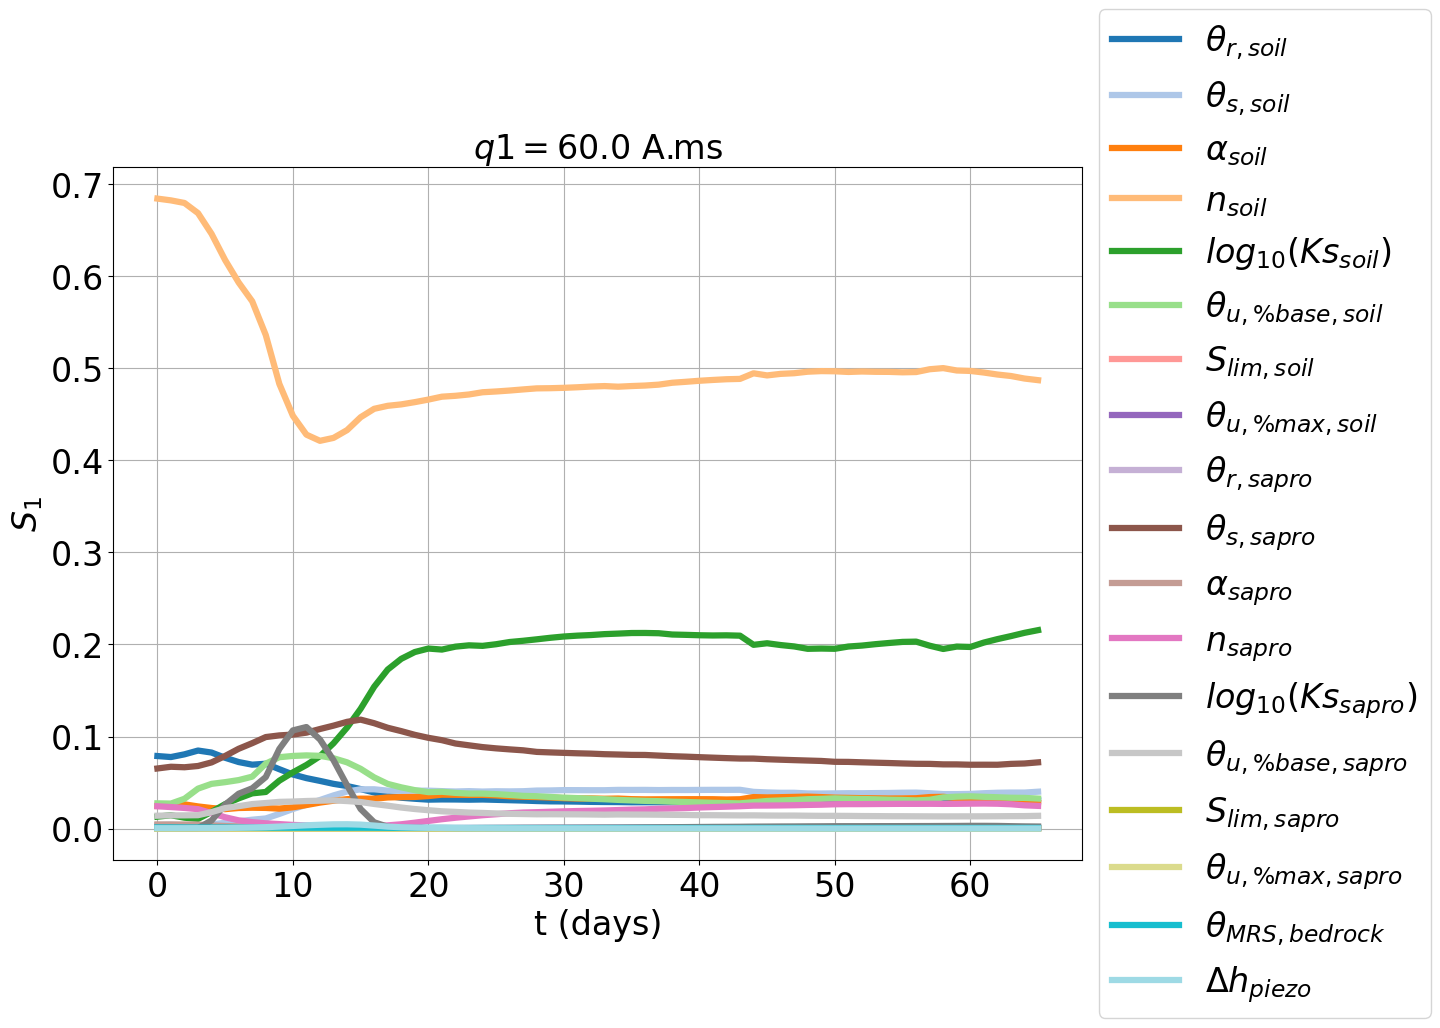

In [12]:
figtitle = 'GSA_5_PCE_Sob_E1_colsiwtch.png'

color = cm.tab20(np.linspace(0, 1, nparams))

fig1 = plt.figure(figsize = figsize)
for i in range(nparams):
    plt.plot(mySobolResultsPCE_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=4.5) 
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.5), fontsize = fs, labelcolor = 'black')
plt.grid()
plt.xlabel('t (days)', fontsize = fs)
plt.ylabel(r'$S_1$', fontsize = fs)
plt.title(r'$q1=60.0$ A.ms', fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(fontsize = fs)
fig1.set_facecolor('white')
fig1.patch.set_alpha(0)
plt.savefig('Figures/Final_fig/Fig_8_9_leg.jpg', bbox_inches='tight', format = 'jpg', dpi=300)

### Load AMA data

In [13]:
f = open(dir+"AMAE_E1_10ksim.pkl", "rb")
AMAE_E1 = pkl.load(f)
f.close()

In [14]:
f = open(dir+"AMAV_E1_10ksim.pkl", "rb")
AMAV_E1 = pkl.load(f)
f.close()

In [15]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAE_E1_ls = np.transpose(AMAE_E1).tolist()
AMAV_E1_ls = np.transpose(AMAV_E1).tolist()

theta_i_percent_base_soil_idx = 10

# Soil
AMAE_theta_i_percent_base_soil_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx)
AMAV_theta_i_percent_base_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_soil_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
AMAV_Slim_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAE_theta_i_percent_max_soil_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx) # same as previous line
AMAV_theta_i_percent_max_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAE_theta_i_percent_base_sapro_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx)
AMAV_theta_i_percent_base_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_sapro_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx) 
AMAV_Slim_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAE_theta_i_percent_max_sapro_temp = AMAE_E1_ls.pop(theta_i_percent_base_soil_idx) 
AMAV_theta_i_percent_max_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAE
AMAE_E1_ls.insert(theta_i_percent_base_soil_new_idx, AMAE_theta_i_percent_base_soil_temp)
AMAE_E1_ls.insert(S_lim_soil_new_idx, AMAE_Slim_soil_temp)
AMAE_E1_ls.insert(theta_i_percent_max_soil_new_idx, AMAE_theta_i_percent_max_soil_temp)

AMAE_E1_ls.insert(theta_i_percent_base_sapro_new_idx, AMAE_theta_i_percent_base_sapro_temp)
AMAE_E1_ls.insert(S_lim_sapro_new_idx, AMAE_Slim_sapro_temp)
AMAE_E1_ls.insert(theta_i_percent_max_sapro_new_idx, AMAE_theta_i_percent_max_sapro_temp)

#AMAV
AMAV_E1_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E1_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E1_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E1_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E1_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E1_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAE_E1_toplot = np.transpose(np.array(AMAE_E1_ls))
AMAV_E1_toplot = np.transpose(np.array(AMAV_E1_ls))

Check swapped columns

In [16]:
AMAE_E1[:,4] == AMAE_E1_toplot[:,4]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [17]:
AMAE_E1[:,10] == AMAE_E1_toplot[:,5]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [18]:
AMAE_E1[:,11] == AMAE_E1_toplot[:,6]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [19]:
AMAE_E1[:,14] == AMAE_E1_toplot[:,14]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [20]:
AMAV_E1[:,4] == AMAV_E1_toplot[:,4]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [21]:
AMAV_E1[:,10] == AMAV_E1_toplot[:,5]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [22]:
AMAV_E1[:,11] == AMAV_E1_toplot[:,6]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [23]:
AMAV_E1[:,14] == AMAV_E1_toplot[:,14]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

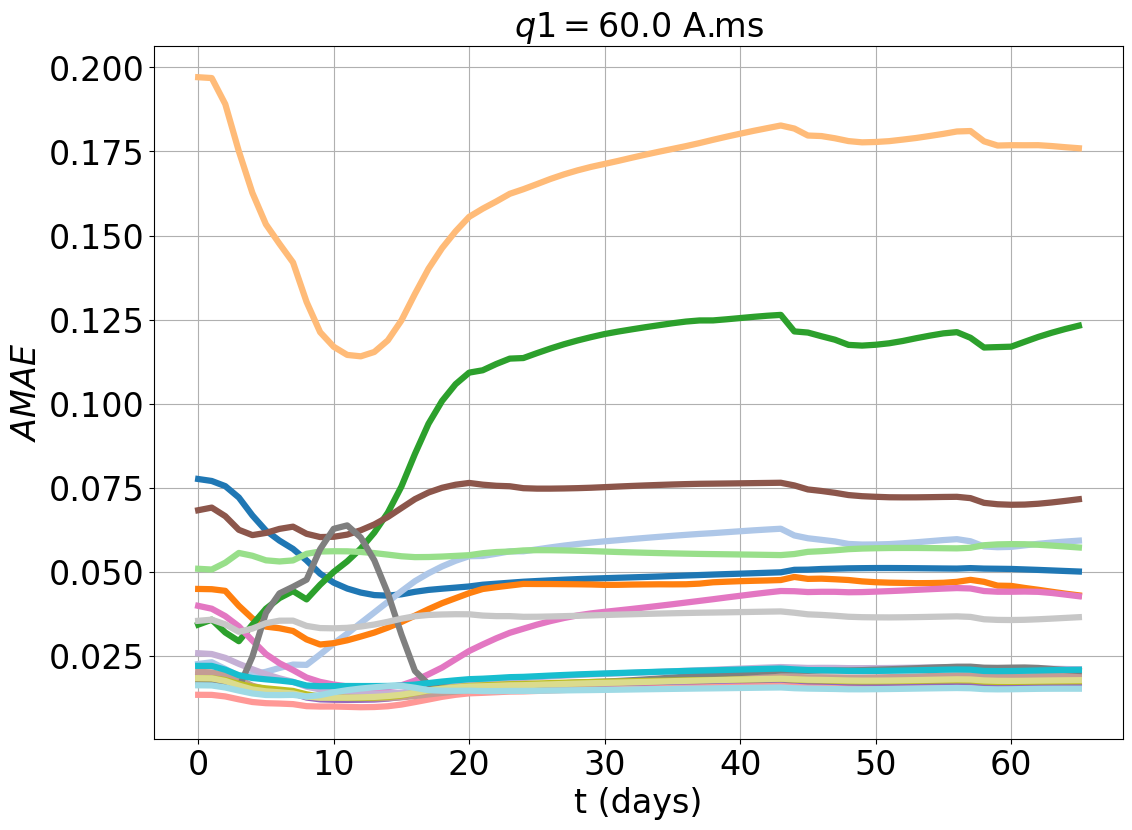

In [24]:
figtitle = 'GSA_5_AMAE_E1.png'

fig1 = plt.figure(figsize = figsize)
for i in range(nparams):
    plt.plot(AMAE_E1_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=4.5) 
plt.grid()
plt.xlabel('t (days)', fontsize = fs)
plt.ylabel(r'$AMAE$', fontsize = fs)
plt.title(r'$q1=60.0$ A.ms', fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(fontsize = fs)
fig1.set_facecolor('white')
fig1.patch.set_alpha(0)

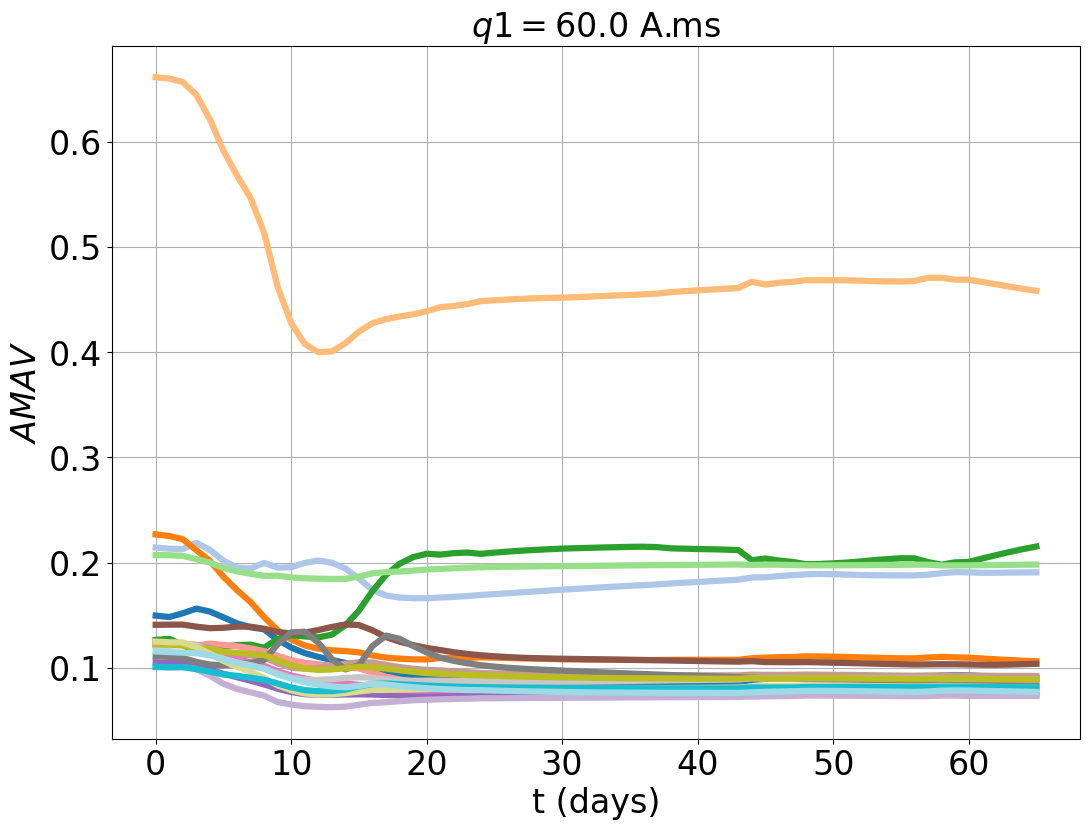

In [25]:
figtitle = 'GSA_5_AMAV_E1.png'

fig2 = plt.figure(figsize = figsize)
for i in range(nparams):
    plt.plot(AMAV_E1_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=4.5) 
plt.grid()
plt.xlabel('t (days)', fontsize = fs)
plt.ylabel(r'$AMAV$', fontsize = fs)
plt.title(r'$q1=60.0$ A.ms', fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(fontsize = fs)
fig1.set_facecolor('white')
fig1.patch.set_alpha(0)

### Common plot

In [26]:
piezo_data = np.loadtxt('Data/Piezometers_Pz3b_Pz5b_Data_1hour_20201101_20210430.csv', dtype='str', skiprows=2, delimiter=';') # Water table levels in pz5b and pz2b
z_table = piezo_data[:,-1].astype('float')

ndays_numexp = 66
h_start = 2082
duration_h = 24*66
h_end = h_start+duration_h


Qtop = np.loadtxt('Data/Qtop_RMPmon.csv', skiprows=1) # Top flux
Qtop_d_numexp = np.zeros(ndays_numexp)

for i in range(ndays_numexp):
    Qtop_d_numexp[i] = np.sum(Qtop[h_start+i*24:h_start+(i+1)*24])

In [27]:
fs=16

# ---------- Convert daily x-values to hourly ----------
nd_bar = ndays_numexp - 1
day_x_bar = np.arange(nd_bar) * 24        # e.g., 0, 24, 48, ...
hour_end_bar = (ndays_numexp - 1) * 24

nd_curve = ndays_numexp 
day_x_curve = np.arange(nd_curve) * 24        # e.g., 0, 24, 48, ...
hour_end_curve = nd_curve * 24

# ---------- DAY TICKS ----------
day_ticks = np.array([0, 10, 20, 30, 40, 50, 60])
hour_ticks = day_ticks * 24       # convert days → hours



In [28]:
AMAE_yticks = np.array([0,0.05,0.10,0.15,0.20])
AMAV_yticks = np.array([0,0.10,0.20,0.30,0.40,0.50,0.60,0.70])
AMAE_ylim = (0,0.21)
AMAV_ylim = (0,0.76)


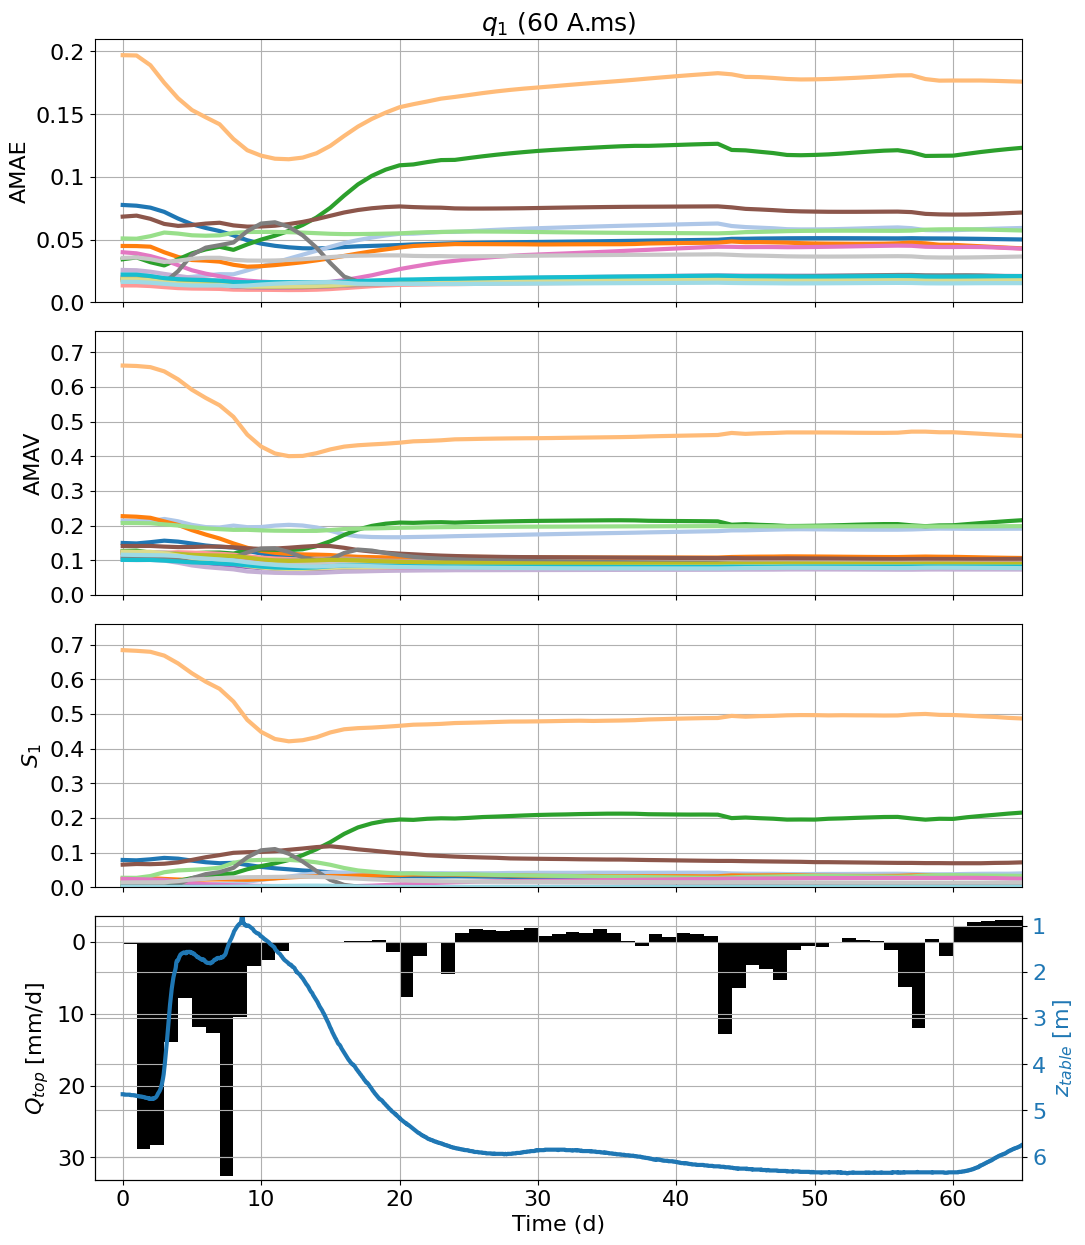

In [29]:
fig, axes = plt.subplots(4, 1, figsize = (10,12), sharex=True)
fig.tight_layout()

axes[0].set_title(r'$q_1$ (60 A.ms)', fontsize = fs+2)

for i in range(nparams):
    axes[0].plot(day_x_curve, AMAE_E1_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[0].set_ylabel(r'AMAE', fontsize=fs)
axes[0].set_yticks(AMAE_yticks, AMAE_yticks.astype('str'), fontsize = fs)
axes[0].set_ylim(AMAE_ylim)
axes[0].grid()

for i in range(nparams):
    axes[1].plot(day_x_curve, AMAV_E1_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[1].set_ylabel(r'AMAV', fontsize=fs)
axes[1].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[1].set_ylim(AMAV_ylim)
axes[1].grid()

for i in range(nparams):
    axes[2].plot(day_x_curve, mySobolResultsPCE_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[2].set_ylabel(r'$S_1$', fontsize=fs)
axes[2].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[2].set_ylim(AMAV_ylim)
axes[2].grid()


axes[3].bar(day_x_bar, Qtop_d_numexp[:-1], width=24, color='k', align='edge')
axes[3].set_ylim((max(Qtop_d_numexp)+0.5, min(Qtop_d_numexp)-0.5))
axes[3].set_yticks([0,10,20,30], ['0','10','20','30'], fontsize = fs)
axes[3].set_ylabel(r'$Q_{top}$ [mm/d]', fontsize=fs)
axes[3].grid()
axes[3].set_xlabel('Time (d)', fontsize=fs)


ax2bis = axes[3].twinx()  # instantiate a second Axes that shares the same x-axis
ax2bis.plot(z_table[h_start:h_end], linewidth=3)
ax2bis.set_ylim((6.5, 0.8))
ax2bis.set_yticks([1,2,3,4,5,6], ['1','2','3','4','5','6'], fontsize = fs, color='C0')
ax2bis.set_ylabel(r'$z_{table}$ [m]', fontsize=fs, color='C0')
ax2bis.set_xlabel('Time (d)', fontsize=fs+2)
ax2bis.grid()


# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:3]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[3].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fs)


# Shared x-limits for perfect alignment
for ax in axes:
    ax.set_xlim(-2*24, hour_end_bar)

plt.savefig('Figures/Final_fig/Fig_8.jpg', format = 'jpg', bbox_inches='tight', dpi = 300)

# Fig. 9 

In [30]:
#AMAE

f = open(dir+"AMAE_E2_10ksim.pkl", "rb")
AMAE_E2 = pkl.load(f)
f.close()

f = open(dir+"AMAE_E3_10ksim.pkl", "rb")
AMAE_E3 = pkl.load(f)
f.close()

f = open(dir+"AMAE_E4_10ksim.pkl", "rb")
AMAE_E4 = pkl.load(f)
f.close()

In [31]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAE_E2_ls = np.transpose(AMAE_E2).tolist()

theta_i_percent_base_soil_idx = 10

# Soil
AMAE_theta_i_percent_base_soil_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_soil_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx

AMAE_theta_i_percent_max_soil_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx) # same as previous line

# Sapro

AMAE_theta_i_percent_base_sapro_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_sapro_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx) 

AMAE_theta_i_percent_max_sapro_temp = AMAE_E2_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAE
AMAE_E2_ls.insert(theta_i_percent_base_soil_new_idx, AMAE_theta_i_percent_base_soil_temp)
AMAE_E2_ls.insert(S_lim_soil_new_idx, AMAE_Slim_soil_temp)
AMAE_E2_ls.insert(theta_i_percent_max_soil_new_idx, AMAE_theta_i_percent_max_soil_temp)

AMAE_E2_ls.insert(theta_i_percent_base_sapro_new_idx, AMAE_theta_i_percent_base_sapro_temp)
AMAE_E2_ls.insert(S_lim_sapro_new_idx, AMAE_Slim_sapro_temp)
AMAE_E2_ls.insert(theta_i_percent_max_sapro_new_idx, AMAE_theta_i_percent_max_sapro_temp)


AMAE_E2_toplot = np.transpose(np.array(AMAE_E2_ls))

In [32]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAE_E3_ls = np.transpose(AMAE_E3).tolist()
theta_i_percent_base_soil_idx = 10

# Soil
AMAE_theta_i_percent_base_soil_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_soil_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx

AMAE_theta_i_percent_max_soil_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx) # same as previous line

# Sapro

AMAE_theta_i_percent_base_sapro_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_sapro_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx) 

AMAE_theta_i_percent_max_sapro_temp = AMAE_E3_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAE
AMAE_E3_ls.insert(theta_i_percent_base_soil_new_idx, AMAE_theta_i_percent_base_soil_temp)
AMAE_E3_ls.insert(S_lim_soil_new_idx, AMAE_Slim_soil_temp)
AMAE_E3_ls.insert(theta_i_percent_max_soil_new_idx, AMAE_theta_i_percent_max_soil_temp)

AMAE_E3_ls.insert(theta_i_percent_base_sapro_new_idx, AMAE_theta_i_percent_base_sapro_temp)
AMAE_E3_ls.insert(S_lim_sapro_new_idx, AMAE_Slim_sapro_temp)
AMAE_E3_ls.insert(theta_i_percent_max_sapro_new_idx, AMAE_theta_i_percent_max_sapro_temp)

AMAE_E3_toplot = np.transpose(np.array(AMAE_E3_ls))

In [33]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAE_E4_ls = np.transpose(AMAE_E4).tolist()

theta_i_percent_base_soil_idx = 10

# Soil
AMAE_theta_i_percent_base_soil_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_soil_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx

AMAE_theta_i_percent_max_soil_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx) # same as previous line

# Sapro

AMAE_theta_i_percent_base_sapro_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_sapro_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx) 

AMAE_theta_i_percent_max_sapro_temp = AMAE_E4_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAE
AMAE_E4_ls.insert(theta_i_percent_base_soil_new_idx, AMAE_theta_i_percent_base_soil_temp)
AMAE_E4_ls.insert(S_lim_soil_new_idx, AMAE_Slim_soil_temp)
AMAE_E4_ls.insert(theta_i_percent_max_soil_new_idx, AMAE_theta_i_percent_max_soil_temp)

AMAE_E4_ls.insert(theta_i_percent_base_sapro_new_idx, AMAE_theta_i_percent_base_sapro_temp)
AMAE_E4_ls.insert(S_lim_sapro_new_idx, AMAE_Slim_sapro_temp)
AMAE_E4_ls.insert(theta_i_percent_max_sapro_new_idx, AMAE_theta_i_percent_max_sapro_temp)

AMAE_E4_toplot = np.transpose(np.array(AMAE_E4_ls))

In [34]:
f = open(dir+"Sobol_E2.pkl", "rb")
mySobolResultsPCE_E2 = pkl.load(f)
f.close()

f = open(dir+"Sobol_E3.pkl", "rb")
mySobolResultsPCE_E3 = pkl.load(f)
f.close()

f = open(dir+"Sobol_E4.pkl", "rb")
mySobolResultsPCE_E4 = pkl.load(f)
f.close()

In [35]:
# Swipe columns to display undetectable water parameters with the other parameters of each layer 
# Work on a copy of the array 

mySobolResultsPCE_E2_toplot = copy.deepcopy(mySobolResultsPCE_E2)

S1_theta_i_percent_base_soil_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_soil_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
S1_theta_i_percent_max_soil_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # same as previous line

S1_theta_i_percent_base_sapro_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_sapro_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 
S1_theta_i_percent_max_sapro_temp = mySobolResultsPCE_E2_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 


mySobolResultsPCE_E2_toplot['FirstOrder'].insert(theta_i_percent_base_soil_new_idx, S1_theta_i_percent_base_soil_temp)
mySobolResultsPCE_E2_toplot['FirstOrder'].insert(S_lim_soil_new_idx, S1_Slim_soil_temp)
mySobolResultsPCE_E2_toplot['FirstOrder'].insert(theta_i_percent_max_soil_new_idx, S1_theta_i_percent_max_soil_temp)

mySobolResultsPCE_E2_toplot['FirstOrder'].insert(theta_i_percent_base_sapro_new_idx, S1_theta_i_percent_base_sapro_temp)
mySobolResultsPCE_E2_toplot['FirstOrder'].insert(S_lim_sapro_new_idx, S1_Slim_sapro_temp)
mySobolResultsPCE_E2_toplot['FirstOrder'].insert(theta_i_percent_max_sapro_new_idx, S1_theta_i_percent_max_sapro_temp)

In [36]:
# Swipe columns to display undetectable water parameters with the other parameters of each layer 
# Work on a copy of the array 

mySobolResultsPCE_E3_toplot = copy.deepcopy(mySobolResultsPCE_E3)

S1_theta_i_percent_base_soil_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_soil_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
S1_theta_i_percent_max_soil_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # same as previous line

S1_theta_i_percent_base_sapro_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_sapro_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 
S1_theta_i_percent_max_sapro_temp = mySobolResultsPCE_E3_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 


mySobolResultsPCE_E3_toplot['FirstOrder'].insert(theta_i_percent_base_soil_new_idx, S1_theta_i_percent_base_soil_temp)
mySobolResultsPCE_E3_toplot['FirstOrder'].insert(S_lim_soil_new_idx, S1_Slim_soil_temp)
mySobolResultsPCE_E3_toplot['FirstOrder'].insert(theta_i_percent_max_soil_new_idx, S1_theta_i_percent_max_soil_temp)

mySobolResultsPCE_E3_toplot['FirstOrder'].insert(theta_i_percent_base_sapro_new_idx, S1_theta_i_percent_base_sapro_temp)
mySobolResultsPCE_E3_toplot['FirstOrder'].insert(S_lim_sapro_new_idx, S1_Slim_sapro_temp)
mySobolResultsPCE_E3_toplot['FirstOrder'].insert(theta_i_percent_max_sapro_new_idx, S1_theta_i_percent_max_sapro_temp)

In [37]:
# Swipe columns to display undetectable water parameters with the other parameters of each layer 
# Work on a copy of the array 

mySobolResultsPCE_E4_toplot = copy.deepcopy(mySobolResultsPCE_E4)

S1_theta_i_percent_base_soil_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_soil_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
S1_theta_i_percent_max_soil_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # same as previous line

S1_theta_i_percent_base_sapro_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_sapro_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 
S1_theta_i_percent_max_sapro_temp = mySobolResultsPCE_E4_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 


mySobolResultsPCE_E4_toplot['FirstOrder'].insert(theta_i_percent_base_soil_new_idx, S1_theta_i_percent_base_soil_temp)
mySobolResultsPCE_E4_toplot['FirstOrder'].insert(S_lim_soil_new_idx, S1_Slim_soil_temp)
mySobolResultsPCE_E4_toplot['FirstOrder'].insert(theta_i_percent_max_soil_new_idx, S1_theta_i_percent_max_soil_temp)

mySobolResultsPCE_E4_toplot['FirstOrder'].insert(theta_i_percent_base_sapro_new_idx, S1_theta_i_percent_base_sapro_temp)
mySobolResultsPCE_E4_toplot['FirstOrder'].insert(S_lim_sapro_new_idx, S1_Slim_sapro_temp)
mySobolResultsPCE_E4_toplot['FirstOrder'].insert(theta_i_percent_max_sapro_new_idx, S1_theta_i_percent_max_sapro_temp)

In [38]:
fs=14

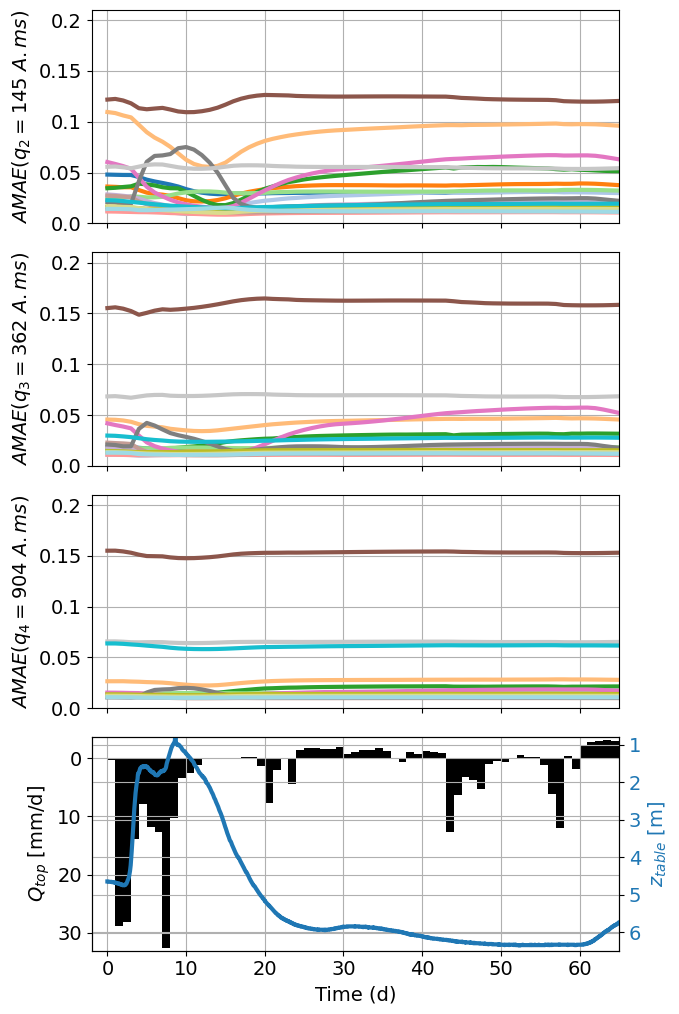

In [39]:
fig, axes = plt.subplots(4, 1, figsize = (6,10), sharex=True)
fig.tight_layout()

for i in range(nparams):
    axes[0].plot(day_x_curve, AMAE_E2_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[0].set_ylabel(r'$AMAE(q_2=145~A.ms)$', fontsize=fs)
axes[0].set_yticks(AMAE_yticks, AMAE_yticks.astype('str'), fontsize = fs)
axes[0].set_ylim(AMAE_ylim)
axes[0].grid()

for i in range(nparams):
    axes[1].plot(day_x_curve, AMAE_E3_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[1].set_ylabel(r'$AMAE(q_3=362~A.ms)$', fontsize=fs)
axes[1].set_yticks(AMAE_yticks, AMAE_yticks.astype('str'), fontsize = fs)
axes[1].set_ylim(AMAE_ylim)
axes[1].grid()

for i in range(nparams):
    axes[2].plot(day_x_curve, AMAE_E4_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[2].set_ylabel(r'$AMAE(q_4=904~A.ms)$', fontsize=fs)
axes[2].set_yticks(AMAE_yticks, AMAE_yticks.astype('str'), fontsize = fs)
axes[2].set_ylim(AMAE_ylim)
axes[2].grid()


axes[3].bar(day_x_bar, Qtop_d_numexp[:-1], width=24, color='k', align='edge')
axes[3].set_ylim((max(Qtop_d_numexp)+0.5, min(Qtop_d_numexp)-0.5))
axes[3].set_yticks([0,10,20,30], ['0','10','20','30'], fontsize = fs)
axes[3].set_ylabel(r'$Q_{top}$ [mm/d]', fontsize=fs)
axes[3].grid()
axes[3].set_xlabel('Time (d)', fontsize=fs)


ax2bis = axes[3].twinx()  # instantiate a second Axes that shares the same x-axis
ax2bis.plot(z_table[h_start:h_end], linewidth=3)
ax2bis.set_ylim((6.5, 0.8))
ax2bis.set_yticks([1,2,3,4,5,6], ['1','2','3','4','5','6'], fontsize = fs, color='C0')
ax2bis.set_ylabel(r'$z_{table}$ [m]', fontsize=fs, color='C0')
ax2bis.set_xlabel('Time (d)', fontsize=fs+2)
ax2bis.grid()


# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:3]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[3].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fs)


# Shared x-limits for perfect alignment
for ax in axes:
    ax.set_xlim(-2*24, hour_end_bar)

plt.savefig('Figures/Final_fig/Fig_9_1.jpg', format = 'jpg', bbox_inches='tight', dpi = 300)

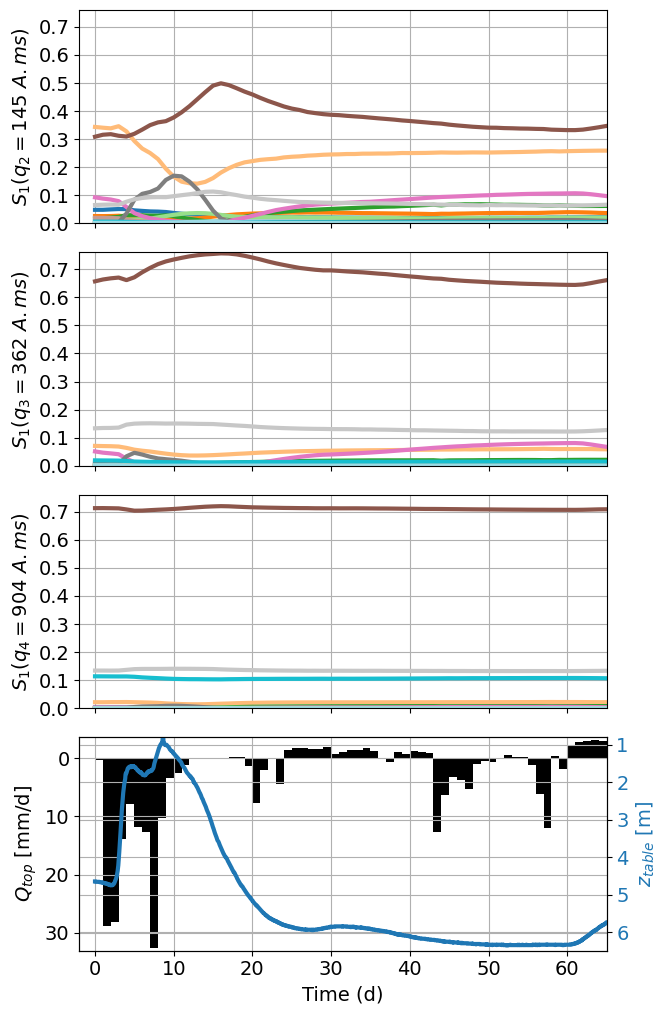

In [40]:
fig, axes = plt.subplots(4, 1, figsize = (6,10), sharex=True)
fig.tight_layout()

for i in range(nparams):
    axes[0].plot(day_x_curve, mySobolResultsPCE_E2_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[0].set_ylabel(r'$S_1(q_2=145~A.ms)$', fontsize=fs)
axes[0].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[0].set_ylim(AMAV_ylim)
axes[0].grid()

for i in range(nparams):
    axes[1].plot(day_x_curve, mySobolResultsPCE_E3_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[1].set_ylabel(r'$S_1(q_3=362~A.ms)$', fontsize=fs)
axes[1].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[1].set_ylim(AMAV_ylim)
axes[1].grid()

for i in range(nparams):
    axes[2].plot(day_x_curve, mySobolResultsPCE_E4_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[2].set_ylabel(r'$S_1(q_4=904~A.ms)$', fontsize=fs)
axes[2].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[2].set_ylim(AMAV_ylim)
axes[2].grid()


axes[3].bar(day_x_bar, Qtop_d_numexp[:-1], width=24, color='k', align='edge')
axes[3].set_ylim((max(Qtop_d_numexp)+0.5, min(Qtop_d_numexp)-0.5))
axes[3].set_yticks([0,10,20,30], ['0','10','20','30'], fontsize = fs)
axes[3].set_ylabel(r'$Q_{top}$ [mm/d]', fontsize=fs)
axes[3].grid()
axes[3].set_xlabel('Time (d)', fontsize=fs)


ax2bis = axes[3].twinx()  # instantiate a second Axes that shares the same x-axis
ax2bis.plot(z_table[h_start:h_end], linewidth=3)
ax2bis.set_ylim((6.5, 0.8))
ax2bis.set_yticks([1,2,3,4,5,6], ['1','2','3','4','5','6'], fontsize = fs, color='C0')
ax2bis.set_ylabel(r'$z_{table}$ [m]', fontsize=fs, color='C0')
ax2bis.set_xlabel('Time (d)', fontsize=fs+2)
ax2bis.grid()


# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:3]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[3].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fs)


# Shared x-limits for perfect alignment
for ax in axes:
    ax.set_xlim(-2*24, hour_end_bar)

plt.savefig('Figures/Final_fig/Fig_9_2.jpg', format = 'jpg', bbox_inches='tight', dpi = 300)

# GSA of q5 for sup. mat. 

In [41]:
f = open(dir+"AMAE_E5_10ksim.pkl", "rb")
AMAE_E5 = pkl.load(f)
f.close()

f = open(dir+"AMAV_E5_10ksim.pkl", "rb")
AMAV_E5 = pkl.load(f)
f.close()

In [42]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAE_E5_ls = np.transpose(AMAE_E5).tolist()
AMAV_E5_ls = np.transpose(AMAV_E5).tolist()

theta_i_percent_base_soil_idx = 10

# Soil
AMAE_theta_i_percent_base_soil_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx)
AMAV_theta_i_percent_base_soil_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_soil_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
AMAV_Slim_soil_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx)

AMAE_theta_i_percent_max_soil_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx) # same as previous line
AMAV_theta_i_percent_max_soil_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAE_theta_i_percent_base_sapro_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx)
AMAV_theta_i_percent_base_sapro_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx)

AMAE_Slim_sapro_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx) 
AMAV_Slim_sapro_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx)

AMAE_theta_i_percent_max_sapro_temp = AMAE_E5_ls.pop(theta_i_percent_base_soil_idx) 
AMAV_theta_i_percent_max_sapro_temp = AMAV_E5_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAE
AMAE_E5_ls.insert(theta_i_percent_base_soil_new_idx, AMAE_theta_i_percent_base_soil_temp)
AMAE_E5_ls.insert(S_lim_soil_new_idx, AMAE_Slim_soil_temp)
AMAE_E5_ls.insert(theta_i_percent_max_soil_new_idx, AMAE_theta_i_percent_max_soil_temp)

AMAE_E5_ls.insert(theta_i_percent_base_sapro_new_idx, AMAE_theta_i_percent_base_sapro_temp)
AMAE_E5_ls.insert(S_lim_sapro_new_idx, AMAE_Slim_sapro_temp)
AMAE_E5_ls.insert(theta_i_percent_max_sapro_new_idx, AMAE_theta_i_percent_max_sapro_temp)

#AMAV
AMAV_E5_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E5_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E5_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E5_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E5_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E5_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAE_E5_toplot = np.transpose(np.array(AMAE_E5_ls))
AMAV_E5_toplot = np.transpose(np.array(AMAV_E5_ls))

In [43]:
#Example of loading pickle binary file 
dir = 'Data/'
f = open(dir+"Sobol_E5.pkl", "rb")
mySobolResultsPCE_E5 = pkl.load(f)
f.close()

In [44]:
# Swipe columns to display undetectable water parameters with the other parameters of each layer 
# Work on a copy of the array 

mySobolResultsPCE_E5_toplot = copy.deepcopy(mySobolResultsPCE_E5)

S1_theta_i_percent_base_soil_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_soil_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # new idx of theta_S_lim_soil S1 after pop is theta_i_sol_idx
S1_theta_i_percent_max_soil_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) # same as previous line

S1_theta_i_percent_base_sapro_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx)
S1_Slim_sapro_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 
S1_theta_i_percent_max_sapro_temp = mySobolResultsPCE_E5_toplot['FirstOrder'].pop(theta_i_percent_base_soil_idx) 


mySobolResultsPCE_E5_toplot['FirstOrder'].insert(theta_i_percent_base_soil_new_idx, S1_theta_i_percent_base_soil_temp)
mySobolResultsPCE_E5_toplot['FirstOrder'].insert(S_lim_soil_new_idx, S1_Slim_soil_temp)
mySobolResultsPCE_E5_toplot['FirstOrder'].insert(theta_i_percent_max_soil_new_idx, S1_theta_i_percent_max_soil_temp)

mySobolResultsPCE_E5_toplot['FirstOrder'].insert(theta_i_percent_base_sapro_new_idx, S1_theta_i_percent_base_sapro_temp)
mySobolResultsPCE_E5_toplot['FirstOrder'].insert(S_lim_sapro_new_idx, S1_Slim_sapro_temp)
mySobolResultsPCE_E5_toplot['FirstOrder'].insert(theta_i_percent_max_sapro_new_idx, S1_theta_i_percent_max_sapro_temp)

In [45]:
AMAE_yticks_q5 = np.array([0,0.05,0.10,0.15,0.20,0.25])
AMAV_yticks_q5 = np.array([0.2,0.4,0.6,0.8])

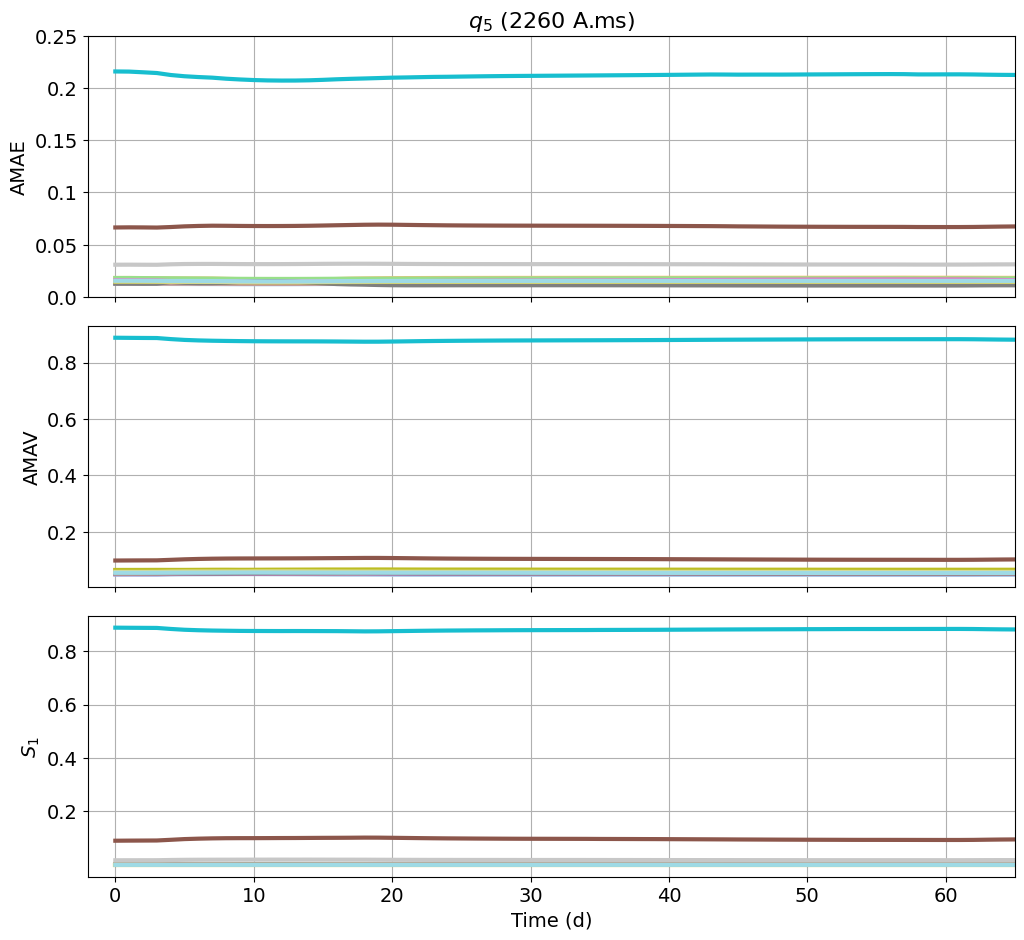

In [46]:
fig, axes = plt.subplots(3, 1, figsize = (10,9), sharex=True)
fig.tight_layout()

axes[0].set_title(r'$q_5$ (2260 A.ms)', fontsize = fs+2)

for i in range(nparams):
    axes[0].plot(day_x_curve, AMAE_E5_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[0].set_ylabel(r'AMAE', fontsize=fs)
axes[0].set_yticks(AMAE_yticks_q5, AMAE_yticks_q5.astype('str'), fontsize = fs)

#axes[0].set_ylim(AMAE_ylim)
axes[0].grid()

for i in range(nparams):
    axes[1].plot(day_x_curve, AMAV_E5_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[1].set_ylabel(r'AMAV', fontsize=fs)
axes[1].set_yticks(AMAV_yticks_q5, AMAV_yticks_q5.astype('str'), fontsize = fs)
#axes[1].set_ylim(AMAV_ylim)
axes[1].grid()

for i in range(nparams):
    axes[2].plot(day_x_curve, mySobolResultsPCE_E5_toplot['FirstOrder'][i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[2].set_ylabel(r'$S_1$', fontsize=fs)
axes[2].set_yticks(AMAV_yticks_q5, AMAV_yticks_q5.astype('str'), fontsize = fs)
#axes[2].set_ylim(AMAV_ylim)
axes[2].grid()



# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:2]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[2].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fs)
axes[2].set_xlabel('Time (d)', fontsize = fs)


# Shared x-limits for perfect alignment
for ax in axes:
    ax.set_xlim(-2*24, hour_end_bar)

plt.savefig('Figures/Sup_mat/GSA_q5.jpg', format = 'jpg', bbox_inches='tight', dpi = 300)

## Fig. AMAV, q2 -> q4 for Sup. Mat. 

In [47]:
f = open(dir+"AMAV_E2_10ksim.pkl", "rb")
AMAV_E2 = pkl.load(f)
f.close()

f = open(dir+"AMAV_E3_10ksim.pkl", "rb")
AMAV_E3 = pkl.load(f)
f.close()

f = open(dir+"AMAV_E4_10ksim.pkl", "rb")
AMAV_E4 = pkl.load(f)
f.close()

f = open(dir+"AMAV_E5_10ksim.pkl", "rb")
AMAV_E5 = pkl.load(f)
f.close()

In [48]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAV_E1_ls = np.transpose(AMAV_E1).tolist()

theta_i_percent_base_soil_idx = 10

# Soil
AMAV_theta_i_percent_base_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_soil_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAV_theta_i_percent_base_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_sapro_temp = AMAV_E1_ls.pop(theta_i_percent_base_soil_idx) 

theta_i_percent_base_soil_new_idx = 5
S_lim_soil_new_idx = 6
theta_i_percent_max_soil_new_idx = 7

theta_i_percent_base_sapro_new_idx = 13
S_lim_sapro_new_idx = 14
theta_i_percent_max_sapro_new_idx = 15


#AMAV
AMAV_E1_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E1_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E1_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E1_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E1_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E1_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAV_E1_toplot = np.transpose(np.array(AMAV_E1_ls))

In [49]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAV_E2_ls = np.transpose(AMAV_E2).tolist()


# Soil
AMAV_theta_i_percent_base_soil_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_soil_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_soil_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAV_theta_i_percent_base_sapro_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_sapro_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_sapro_temp = AMAV_E2_ls.pop(theta_i_percent_base_soil_idx) 


#AMAV
AMAV_E2_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E2_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E2_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E2_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E2_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E2_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAV_E2_toplot = np.transpose(np.array(AMAV_E2_ls))

In [50]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro
AMAV_E3_ls = np.transpose(AMAV_E3).tolist()

# Soil
AMAV_theta_i_percent_base_soil_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_soil_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_soil_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAV_theta_i_percent_base_sapro_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_sapro_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_sapro_temp = AMAV_E3_ls.pop(theta_i_percent_base_soil_idx) 

#AMAV
AMAV_E3_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E3_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E3_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E3_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E3_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E3_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAV_E3_toplot = np.transpose(np.array(AMAV_E3_ls))

In [51]:
# Switch columns to put soil MRS invisible water parameter after soil VG parameters and same for sapro

AMAV_E4_ls = np.transpose(AMAV_E4).tolist()


# Soil
AMAV_theta_i_percent_base_soil_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_soil_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_soil_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx)

# Sapro

AMAV_theta_i_percent_base_sapro_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAV_Slim_sapro_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx)

AMAV_theta_i_percent_max_sapro_temp = AMAV_E4_ls.pop(theta_i_percent_base_soil_idx) 

#AMAV
AMAV_E4_ls.insert(theta_i_percent_base_soil_new_idx, AMAV_theta_i_percent_base_soil_temp)
AMAV_E4_ls.insert(S_lim_soil_new_idx, AMAV_Slim_soil_temp)
AMAV_E4_ls.insert(theta_i_percent_max_soil_new_idx, AMAV_theta_i_percent_max_soil_temp)

AMAV_E4_ls.insert(theta_i_percent_base_sapro_new_idx, AMAV_theta_i_percent_base_sapro_temp)
AMAV_E4_ls.insert(S_lim_sapro_new_idx, AMAV_Slim_sapro_temp)
AMAV_E4_ls.insert(theta_i_percent_max_sapro_new_idx, AMAV_theta_i_percent_max_sapro_temp)

AMAV_E4_toplot = np.transpose(np.array(AMAV_E4_ls))

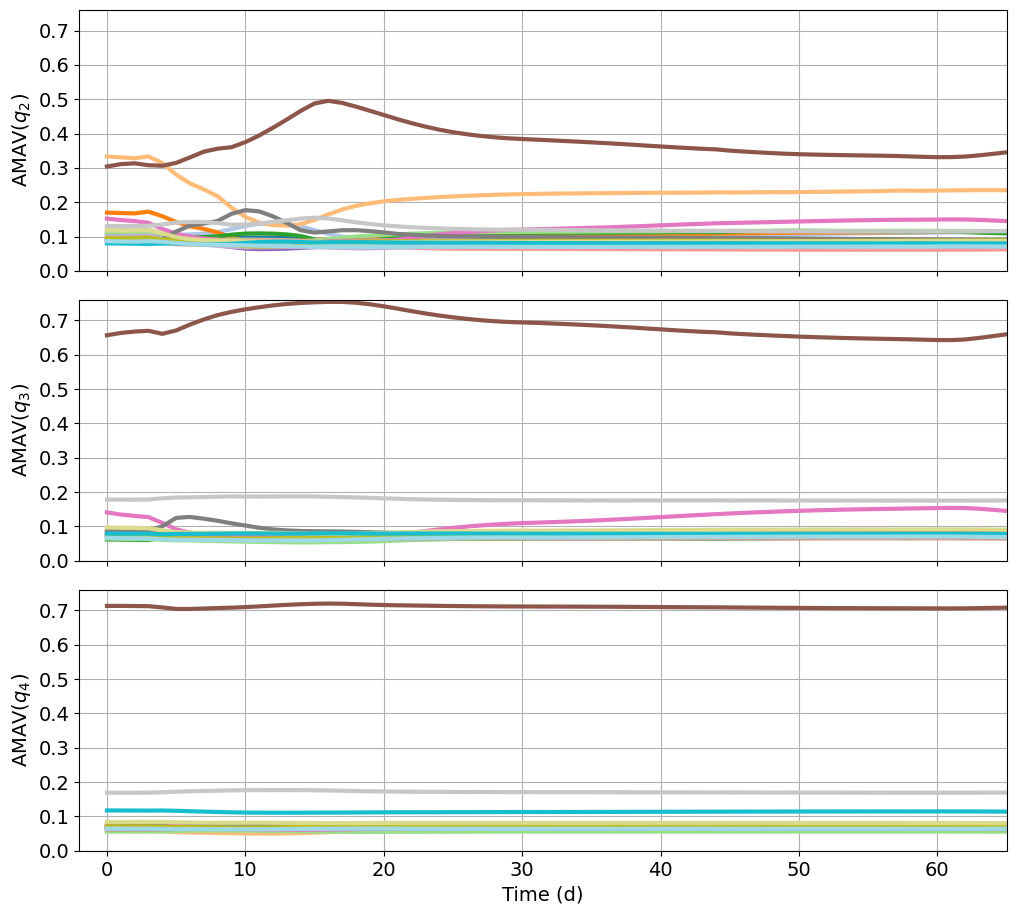

In [52]:
fig, axes = plt.subplots(3, 1, figsize = (10,9), sharex=True)
fig.tight_layout()

for i in range(nparams):
    axes[0].plot(day_x_curve, AMAV_E2_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[0].set_ylabel(r'AMAV($q_2$)', fontsize=fs)
axes[0].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)

axes[0].set_ylim(AMAV_ylim)
axes[0].grid()

for i in range(nparams):
    axes[1].plot(day_x_curve, AMAV_E3_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[1].set_ylabel(r'AMAV($q_3$)', fontsize=fs)
axes[1].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[1].set_ylim(AMAV_ylim)
axes[1].grid()

for i in range(nparams):
    axes[2].plot(day_x_curve, AMAV_E4_toplot[:,i], label = pname_colswitch[i], color = color[i], linewidth=3) 
axes[2].set_ylabel(r'AMAV($q_4$)', fontsize=fs)
axes[2].set_yticks(AMAV_yticks, AMAV_yticks.astype('str'), fontsize = fs)
axes[2].set_ylim(AMAV_ylim)
axes[2].grid()



# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:2]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[2].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fs)
axes[2].set_xlabel('Time (d)', fontsize = fs)


# Shared x-limits for perfect alignment
for ax in axes:
    ax.set_xlim(-2*24, hour_end_bar)

plt.savefig('Figures/Sup_mat/AMAV_q2_q4.jpg', format = 'jpg', bbox_inches='tight', dpi = 300)